#  Hindi Verbal Fluency

**Authors:** Akshat Kotadia (2025201005) · Om Mehra (2025201008) · Ankit Chavda (2025201045)  
**Institution:** IIIT Hyderabad · **Date:** March 2026


---
## Import Libraries and Setup

All required libraries are imported here. Visualisation defaults are configured once.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, ast, re, os
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde, ttest_ind

import nltk
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)

# ── Visualisation defaults ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':         120,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.size':          11,
    'font.family':        'DejaVu Sans',
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
})
PALETTE     = sns.color_palette("Set2")
DOMAINS_ORD = ['animals', 'foods', 'colours', 'body-parts']
DOM_COLORS  = dict(zip(DOMAINS_ORD, PALETTE[:4]))

PALETTE_DICT = {
    'blue':   '#4C72B0', 'orange': '#DD8452', 'green':  '#55A868',
    'red':    '#C44E52', 'purple': '#8172B3', 'brown':  '#937860',
    'pink':   '#DA8BC3', 'gray':   '#8C8C8C', 'teal':   '#6AAFBE',
}
GENDER_COLORS = {
    'Male': '#4C72B0', 'Female': '#DD8452',
    'Non-binary': '#55A868', 'Prefer not to say': '#8C8C8C',
}
THRESHOLD_MS = 60_000

# ── Helper: right-column interpretation panel ────────────────────────────────
def add_interp(ax_text, text):
    ax_text.axis('off')
    ax_text.text(
        0.05, 0.95, text, transform=ax_text.transAxes,
        fontsize=10, va='top', ha='left', wrap=True,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FAFAFA',
                  edgecolor='#CCCCCC', alpha=0.9)
    )

print("Libraries loaded. Constants set.")
print(f"THRESHOLD_MS = {THRESHOLD_MS:,} ms  |  Domains = {DOMAINS_ORD}")

Libraries loaded. Constants set.
THRESHOLD_MS = 60,000 ms  |  Domains = ['animals', 'foods', 'colours', 'body-parts']


In [2]:
# Build English vocabulary from WordNet for language classification
lemmatizer = WordNetLemmatizer()
english_vocab = set()
for synset in wn.all_synsets():
    for lemma in synset.lemma_names():
        english_vocab.add(lemma.lower())

print(f"English vocabulary size: {len(english_vocab):,} tokens")

English vocabulary size: 147,306 tokens


---
## Language Classification Function

`classify_language()` detects Hindi/Hinglish script (Devanagari Unicode U+0900–U+097F) and falls back to WordNet lexicon matching for pure-Roman Hinglish versus English. Each VFT response word is tagged individually.

In [3]:
def classify_language(text):
    """Tag a single word/token as 'Hindi/Hinglish' or 'English'.

    Rules (in priority order):
      1. Any Devanagari character → Hindi/Hinglish
      2. ≥50 % of whitespace-split tokens found in English WordNet → English
      3. Otherwise → Hindi/Hinglish (Romanised Hinglish default)
    """
    text_clean = re.sub(r"[^\w\s]", "", text).lower().strip()
    if text_clean == "":
        return "Other"

    # Rule 1: Devanagari Unicode block U+0900–U+097F
    for char in text_clean:
        if '\u0900' <= char <= '\u097F':
            return "Hindi/Hinglish"

    # Rule 2: WordNet lexicon vote
    tokens = text_clean.split()
    english_count = sum(1 for t in tokens if t in english_vocab)
    if english_count >= len(tokens) / 2:
        return "English"

    return "Hindi/Hinglish"

# Quick sanity check
test_words = ["cat", "बिल्ली", "chai", "animal", "बकरी"]
for w in test_words:
    print(f"  '{w}' → {classify_language(w)}")

  'cat' → English
  'बिल्ली' → Hindi/Hinglish
  'chai' → Hindi/Hinglish
  'animal' → English
  'बकरी' → Hindi/Hinglish


---
## Load Raw Experiment Data

`responses.json` stores all session records under the `"fluency-spam"` key. Each participant entry contains a `subject_id` and a `data` list of trial objects. The flat-row expansion produces one row per trial.

In [4]:
DATA_DIR = os.path.dirname(os.path.abspath("responses.json"))

with open("responses.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

print("Top-level keys:", list(raw.keys()))

exp = raw["fluency-spam"]
print(f"Participants in session: {len(exp)}")

# ── Flatten all trial records into one row per trial ──────────────────────────
rows = []
for session_id, participant in exp.items():
    subject_id = participant["subject_id"]
    for trial in participant["data"]:
        trial_copy = trial.copy()
        trial_copy["subject_id"]  = subject_id
        trial_copy["session_id"]  = session_id
        rows.append(trial_copy)

df = pd.DataFrame(rows)
print(f"\nAll trials shape: {df.shape}")
print("Trial types:", df["trial_type"].value_counts().to_dict())
print("Tasks:", df["task"].value_counts(dropna=False).to_dict())

Top-level keys: ['fluency-spam']
Participants in session: 35

All trials shape: (949, 38)
Trial types: {'html-button-response': 455, 'survey-html-form': 210, 'html-keyboard-response': 144, 'call-function': 35, 'instructions': 35, 'survey-multi-choice': 35, 'survey-text': 35}
Tasks: {nan: 665, 'VFT': 144, 'SpAM': 140}


---
## Extract and Build VFT Trial-Level Dataset

VFT trials contain `tagged_responses` (list of word objects) and `response_times` (list of IRTs in ms). Each word is unpacked into one row with columns: `subject_id`, `domain`, `word`, `rt_ms` (IRT), and `position` (serial order within domain).

In [5]:
# ── Isolate VFT trials ────────────────────────────────────────────────────────
vft_trials = df[df["task"] == "VFT"].copy()
print(f"VFT trial rows: {vft_trials.shape[0]}")

# ── Unpack word-level responses ───────────────────────────────────────────────
vft_rows = []

for _, row in vft_trials.iterrows():
    try:
        words = ast.literal_eval(row["tagged_responses"])
        rts   = ast.literal_eval(row["response_times"])
    except Exception as e:
        print(f"  Parsing error for subject {row['subject_id']}: {e}")
        continue

    if len(words) != len(rts):
        print(f"  Length mismatch – subject {row['subject_id']}, domain {row['domain']}")
        continue

    for idx, (w, rt) in enumerate(zip(words, rts), start=1):
        vft_rows.append({
            "subject_id": row["subject_id"],
            "session_id": row["session_id"],
            "domain":     row["domain"],
            "word":       w["response"].lower().strip(),
            "rt_ms":      float(rt),
            "position":   idx,
        })

vft_df = pd.DataFrame(vft_rows)
print(f"\nvft_df shape: {vft_df.shape}")
print(vft_df["domain"].value_counts())

# ── Remove practice domains ───────────────────────────────────────────────────
vft_df_clean = vft_df[~vft_df["domain"].str.contains("practice", case=False)].copy()
print(f"\nAfter removing practice domains: {vft_df_clean.shape[0]} rows")
print(vft_df_clean["domain"].value_counts())

VFT trial rows: 144

vft_df shape: (1232, 6)
domain
animals               365
foods                 326
body-parts            206
furniture-practice    188
colours               147
Name: count, dtype: int64

After removing practice domains: 1044 rows
domain
animals       365
foods         326
body-parts    206
colours       147
Name: count, dtype: int64


---
## Assign Language Tags and Filter Dataset

Each word is classified by `classify_language()`. A binary column `lang_binary` collapses all Hindi/Hinglish variants. After IRT outlier removal (>60 000 ms), `df_hh` retains only Hindi/Hinglish-dominant sessions for the main analysis.

In [6]:
# ── Tag each word with language classification ────────────────────────────────
vft_df_clean["language_type"] = vft_df_clean["word"].apply(classify_language)

# ── Collapse to binary label ──────────────────────────────────────────────────
vft_df_clean["lang_binary"] = vft_df_clean["language_type"].apply(
    lambda x: "Hindi/Hinglish" if "Hindi" in str(x) else "English"
)

# ── Outlier removal: IRTs > 60 s are excluded ────────────────────────────────
df = vft_df_clean.copy()
df["is_outlier_rt"] = df["rt_ms"] > THRESHOLD_MS
n_out = df["is_outlier_rt"].sum()
df_clean = df[~df["is_outlier_rt"]].copy()
df_clean["irt_sec"] = df_clean["rt_ms"] / 1000

# ── Hindi/Hinglish subset ─────────────────────────────────────────────────────
df_hh = df_clean[df_clean["lang_binary"] == "Hindi/Hinglish"].copy()
domains_ord = DOMAINS_ORD
dom_colors  = DOM_COLORS

print(f"Outliers removed (>{THRESHOLD_MS/1000:.0f} s): {n_out}")
print(f"Total rows after filtering  : {len(df_clean)}")
print(f"Hindi/Hinglish rows         : {len(df_hh)}")
print(f"Participants                : {df_clean['subject_id'].nunique()}")
print(f"Language distribution:\n{df_clean['lang_binary'].value_counts().to_string()}")

Outliers removed (>60 s): 0
Total rows after filtering  : 1044
Hindi/Hinglish rows         : 712
Participants                : 35
Language distribution:
lang_binary
Hindi/Hinglish    712
English           332


---
## Extract Participant Demographics

Age, years of education, state/UT, and gender are extracted from the session JSON. One record per participant is collected; missing fields are skipped.

In [7]:
top = raw.get("fluency-spam", raw)

# ── Extract one record per participant ───────────────────────────────────────
records = []
for pid, pdata in top.items():
    if not isinstance(pdata, dict):
        continue
    rec = {}
    # Pattern 1: fields attached directly to participant object
    for key in ("age", "education", "state_ut", "gender"):
        if key in pdata:
            rec[key] = pdata[key]
    # Pattern 2: fields embedded inside data trial list (survey trial)
    for entry in pdata.get("data", []):
        if not isinstance(entry, dict):
            continue
        for key in ("age", "education", "state_ut", "gender"):
            if key in entry and key not in rec:
                rec[key] = entry[key]
    if rec:
        records.append(rec)

ages, edus, states, genders = [], [], [], []
for r in records:
    try:    ages.append(int(r["age"]))
    except: pass
    try:    edus.append(int(r["education"]))
    except: pass
    if "state_ut" in r and str(r["state_ut"]).strip():
        states.append(str(r["state_ut"]).strip())
    if "gender" in r and str(r["gender"]).strip():
        genders.append(str(r["gender"]).strip())

print(f"Records parsed  : {len(records)}")
print(f"Ages ({len(ages)})     : M={np.mean(ages):.1f}, SD={np.std(ages):.1f}, Range={min(ages)}–{max(ages)}" if ages else "No age data")
print(f"Education ({len(edus)}): M={np.mean(edus):.1f} yrs" if edus else "No education data")
print(f"States ({len(states)})  : {Counter(states).most_common(5)}")
print(f"Genders ({len(genders)}): {Counter(genders)}")

Records parsed  : 35
Ages (35)     : M=23.1, SD=2.0, Range=19–27
Education (35): M=16.5 yrs
States (35)  : [('Gujarat', 7), ('Madhya Pradesh', 6), ('Bihar', 5), ('Maharashtra', 4), ('Chhattisgarh', 2)]
Genders (35): Counter({'Male': 32, 'Female': 3})


---
## Demographics Visualisation

A 2×2 composite panel shows gender (pie), age (histogram), education (bar), and state/UT distribution (horizontal bar). Colour coding distinguishes gender groups and geographic zones.

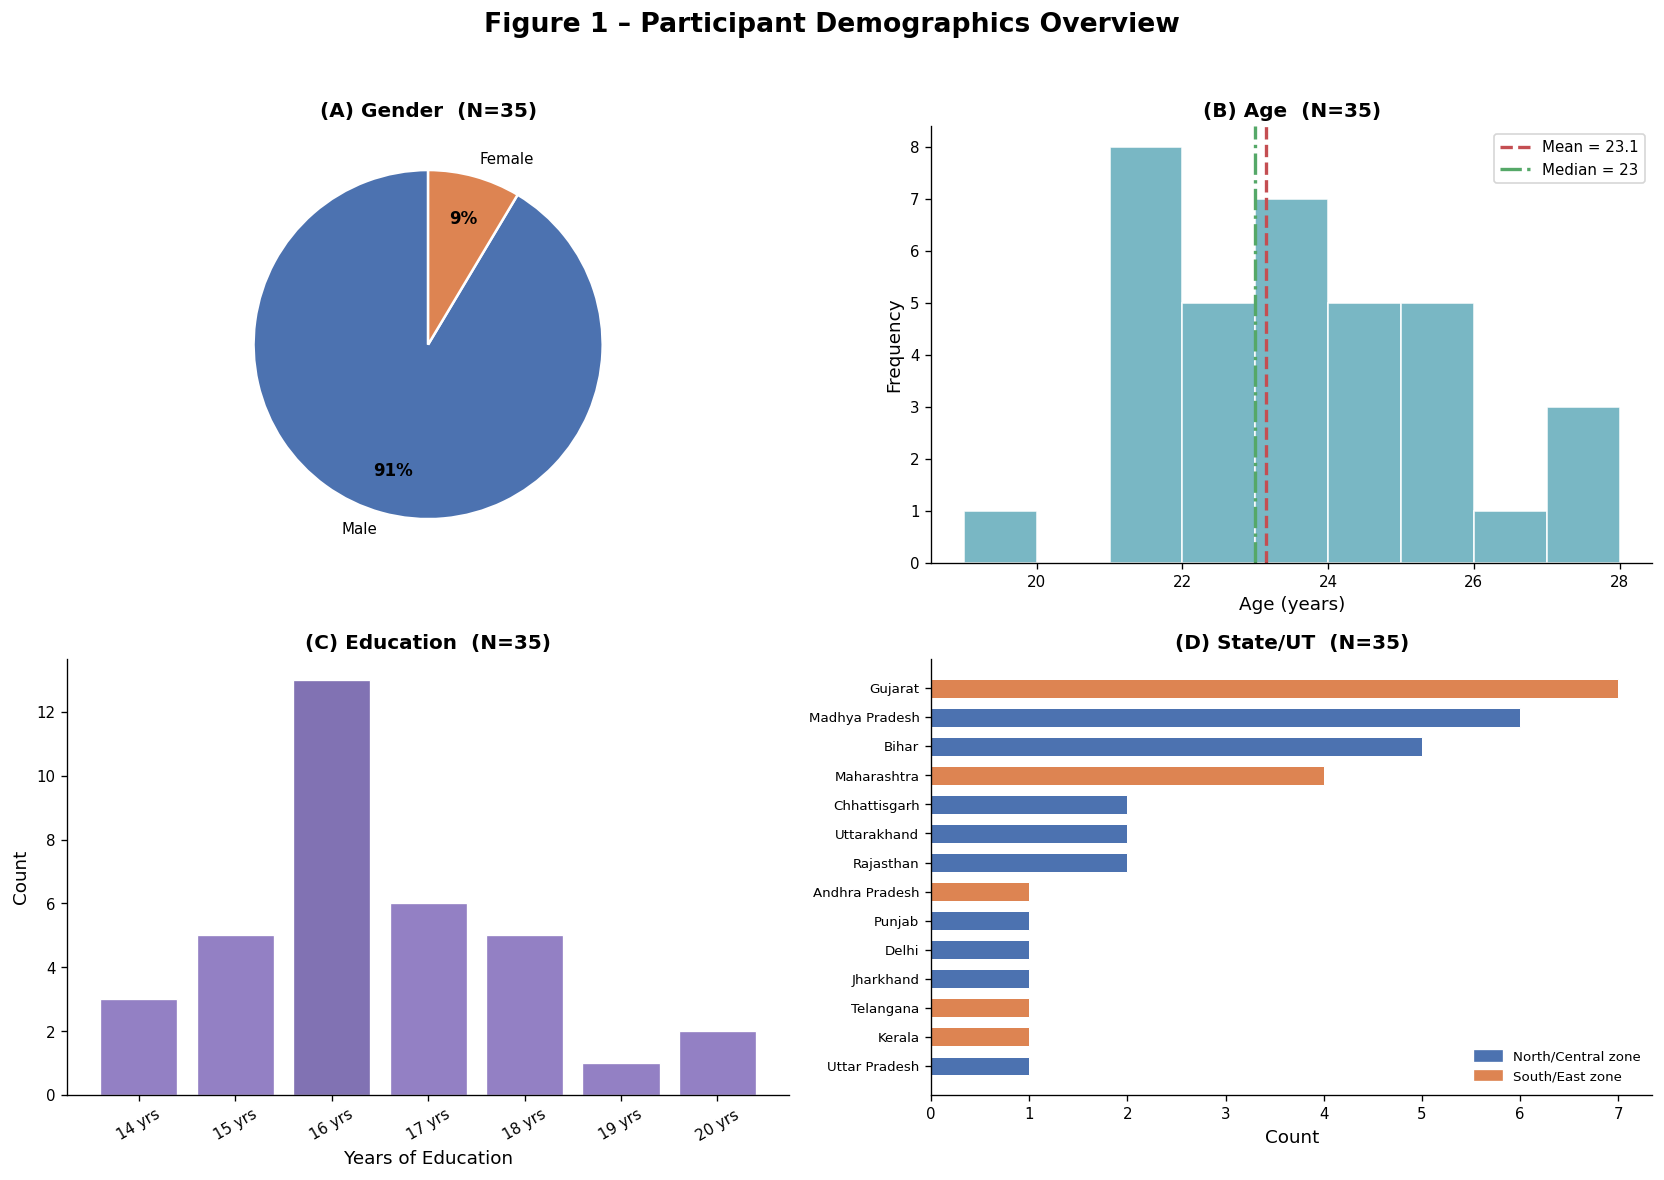


Gender  : {'Male': 32, 'Female': 3}
Age     : M=23.1, SD=2.0, Med=23
Education: M=16.5 yrs
Top states: [('Gujarat', 7), ('Madhya Pradesh', 6), ('Bihar', 5)]


In [8]:
gender_counts = Counter(genders)
g_labels = [k.strip().title() for k in gender_counts.keys()]
g_values = list(gender_counts.values())
g_colors = [GENDER_COLORS.get(l, '#8C8C8C') for l in g_labels]

edu_counts = Counter(edus)
edu_sorted = sorted(edu_counts.items())
edu_labels = [f'{k} yrs' for k, _ in edu_sorted]
edu_vals   = [v for _, v in edu_sorted]

state_counts = Counter(states)
state_sorted = state_counts.most_common()
s_labels = [s for s, _ in state_sorted]
s_vals   = [v for _, v in state_sorted]
north_states = {
    'Uttar Pradesh', 'Bihar', 'Rajasthan', 'Madhya Pradesh',
    'Chhattisgarh', 'Jharkhand', 'Uttarakhand', 'Haryana',
    'Punjab', 'Himachal Pradesh', 'Delhi', 'Jammu and Kashmir',
}
s_colors = [PALETTE_DICT['blue'] if s in north_states else PALETTE_DICT['orange']
            for s in s_labels]

fig = plt.figure(figsize=(14, 10))
fig.suptitle('Figure 1 – Participant Demographics Overview',
             fontsize=16, fontweight='bold', y=0.98)

# ── Panel A: Gender pie ───────────────────────────────────────────────────────
ax_g = fig.add_subplot(2, 2, 1)
wedges, texts, autotexts = ax_g.pie(
    g_values, labels=g_labels, colors=g_colors, autopct='%1.0f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax_g.set_title(f'(A) Gender  (N={len(genders)})', fontweight='bold', fontsize=12)

# ── Panel B: Age histogram ────────────────────────────────────────────────────
ax_a = fig.add_subplot(2, 2, 2)
ax_a.hist(ages, bins=range(min(ages), max(ages) + 2, 1),
          color=PALETTE_DICT['teal'], edgecolor='white', alpha=0.9)
ax_a.axvline(np.mean(ages), color=PALETTE_DICT['red'], lw=2, ls='--',
             label=f'Mean = {np.mean(ages):.1f}')
ax_a.axvline(np.median(ages), color=PALETTE_DICT['green'], lw=2, ls='-.',
             label=f'Median = {np.median(ages):.0f}')
ax_a.set_xlabel('Age (years)')
ax_a.set_ylabel('Frequency')
ax_a.set_title(f'(B) Age  (N={len(ages)})', fontweight='bold', fontsize=12)
ax_a.legend(fontsize=9)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ── Panel C: Education bar ────────────────────────────────────────────────────
ax_e = fig.add_subplot(2, 2, 3)
ax_e.bar(
    edu_labels, edu_vals,
    color=[PALETTE_DICT['purple'] if v == max(edu_vals) else '#9380C4' for v in edu_vals],
    edgecolor='white', linewidth=0.8)
ax_e.set_xlabel('Years of Education')
ax_e.set_ylabel('Count')
ax_e.set_title(f'(C) Education  (N={len(edus)})', fontweight='bold', fontsize=12)
ax_e.tick_params(axis='x', rotation=30)
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

# ── Panel D: State horizontal bar ────────────────────────────────────────────
ax_s = fig.add_subplot(2, 2, 4)
yp = range(len(s_labels))
ax_s.barh(list(yp), s_vals, color=s_colors, edgecolor='white', linewidth=0.6, height=0.65)
ax_s.set_yticks(list(yp))
ax_s.set_yticklabels(s_labels, fontsize=8)
ax_s.set_xlabel('Count')
ax_s.set_title(f'(D) State/UT  (N={len(states)})', fontweight='bold', fontsize=12)
ax_s.invert_yaxis()
ax_s.spines['top'].set_visible(False)
ax_s.spines['right'].set_visible(False)

north_patch = mpatches.Patch(color=PALETTE_DICT['blue'],   label='North/Central zone')
south_patch = mpatches.Patch(color=PALETTE_DICT['orange'],  label='South/East zone')
ax_s.legend(handles=[north_patch, south_patch], frameon=False, fontsize=8, loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\nGender  : {dict(gender_counts)}")
print(f"Age     : M={np.mean(ages):.1f}, SD={np.std(ages):.1f}, Med={np.median(ages):.0f}")
print(f"Education: M={np.mean(edus):.1f} yrs")
print(f"Top states: {state_counts.most_common(3)}")

---
## IRT Descriptive Statistics

In [9]:
def rich_stats(series, label="rt_ms"):
    q1, q2, q3 = series.quantile([0.25, 0.50, 0.75])
    mode_val = series.mode().iloc[0] if not series.mode().empty else np.nan
    return pd.DataFrame({
        'Statistic': [
            'N', 'Mean', 'Median', 'Mode', 'Std Dev', 'Variance',
            'Min', 'Max', 'Range', 'Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)',
            'IQR', 'Skewness', 'Kurtosis'
        ],
        label: [
            len(series), round(series.mean(), 2), round(q2, 2),
            round(mode_val, 2), round(series.std(), 2), round(series.var(), 2),
            round(series.min(), 2), round(series.max(), 2),
            round(series.max() - series.min(), 2),
            round(q1, 2), round(q2, 2), round(q3, 2),
            round(q3 - q1, 2),
            round(series.skew(), 4), round(series.kurtosis(), 4)
        ]
    })

overall = rich_stats(df_hh['rt_ms'], label='Hindi/Hinglish IRT (ms)')
print("OVERALL IRT DESCRIPTIVE STATISTICS  –  Hindi/Hinglish")
print(overall.to_string(index=False))

print("\nBY DOMAIN")
by_domain = df_hh.groupby('domain')['rt_ms'].agg(
    N='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Skewness='skew'
).round(2)
print(by_domain.to_string())

OVERALL IRT DESCRIPTIVE STATISTICS  –  Hindi/Hinglish
Statistic  Hindi/Hinglish IRT (ms)
        N             7.120000e+02
     Mean             6.489520e+03
   Median             5.389400e+03
     Mode             6.410000e+03
  Std Dev             5.018800e+03
 Variance             2.518832e+07
      Min             7.328000e+02
      Max             4.263440e+04
    Range             4.190160e+04
 Q1 (25%)             3.280820e+03
 Q2 (50%)             5.389400e+03
 Q3 (75%)             8.155580e+03
      IQR             4.874750e+03
 Skewness             2.543800e+00
 Kurtosis             9.888600e+00

BY DOMAIN
              N     Mean  Median      Std     Min      Max       Q1       Q3  Skewness
domain                                                                                
animals     238  6390.84  5413.7  4646.99   790.2  42634.4  3636.62  8018.18      3.06
body-parts  177  6872.40  5723.6  4993.75  1012.8  32356.9  3852.10  8457.90      2.51
colours      41  4975.30  3

---
## Language Distribution (All Participants)


Domain-Level Counts
Domain          Hindi tokens  % of total
------------------------------------------
Animals                  238        33.4%
Body-parts               177        24.9%
Colours                   41         5.8%
Foods                    256        36.0%
------------------------------------------
Total                    712         100%

Animals and Foods dominate; Colours has the fewest Hindi tokens
because the small Devanagari colour lexicon (~15 items) is quickly
exhausted, after which participants switch to English.


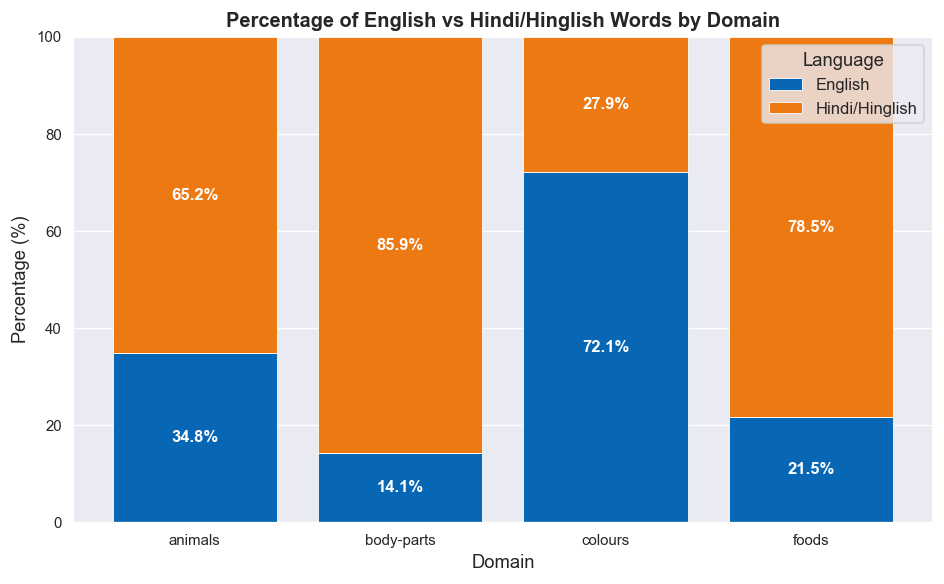

In [40]:
# ── Domain-Level Hindi token counts ──────────────────────────────────────────
lang_counts = df_clean.groupby(['domain', 'lang_binary']).size().unstack(fill_value=0)

# Ensure both columns exist
for col in ['Hindi/Hinglish', 'English']:
    if col not in lang_counts.columns:
        lang_counts[col] = 0

lang_counts['total'] = lang_counts['Hindi/Hinglish'] + lang_counts['English']
lang_counts['hindi_pct'] = (lang_counts['Hindi/Hinglish'] / lang_counts['total'] * 100).round(1)
lang_counts['english_pct'] = (lang_counts['English'] / lang_counts['total'] * 100).round(1)

# ── Print Domain-Level Counts table ──────────────────────────────────────────
total_hindi = lang_counts['Hindi/Hinglish'].sum()
print("Domain-Level Counts")
print(f"{'Domain':<14} {'Hindi tokens':>13} {'% of total':>11}")
print("-" * 42)
for dom in sorted(lang_counts.index):
    h = lang_counts.loc[dom, 'Hindi/Hinglish']
    pct = h / total_hindi * 100
    print(f"{dom.capitalize():<14} {h:>13}    {pct:>8.1f}%")
print("-" * 42)
print(f"{'Total':<14} {total_hindi:>13}    {'100%':>9}")

print(f"\nAnimals and Foods dominate; Colours has the fewest Hindi tokens")
print(f"because the small Devanagari colour lexicon (~15 items) is quickly")
print(f"exhausted, after which participants switch to English.")

# ── Stacked 100% bar chart ────────────────────────────────────────────────────
domains_sorted = sorted(lang_counts.index)
eng_pcts = [lang_counts.loc[d, 'english_pct'] for d in domains_sorted]
hin_pcts = [lang_counts.loc[d, 'hindi_pct']   for d in domains_sorted]

fig, ax = plt.subplots(figsize=(8, 5))

bars_eng = ax.bar(domains_sorted, eng_pcts,
                  color="#0767B5", label='English', edgecolor='white', linewidth=0.5)
bars_hin = ax.bar(domains_sorted, hin_pcts, bottom=eng_pcts,
                  color="#ED7913", label='Hindi/Hinglish', edgecolor='white', linewidth=0.5)

# Label English segment
for bar, val in zip(bars_eng, eng_pcts):
    if val > 5:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f'{val:.1f}%', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

# Label Hindi/Hinglish segment
for bar, eng_val, hin_val in zip(bars_hin, eng_pcts, hin_pcts):
    if hin_val > 5:
        ax.text(bar.get_x() + bar.get_width() / 2,
                eng_val + hin_val / 2,
                f'{hin_val:.1f}%', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_xlabel('Domain', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Percentage of English vs Hindi/Hinglish Words by Domain',
             fontsize=12, fontweight='bold')
ax.legend(title='Language', fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Participant-Level Language Dominance

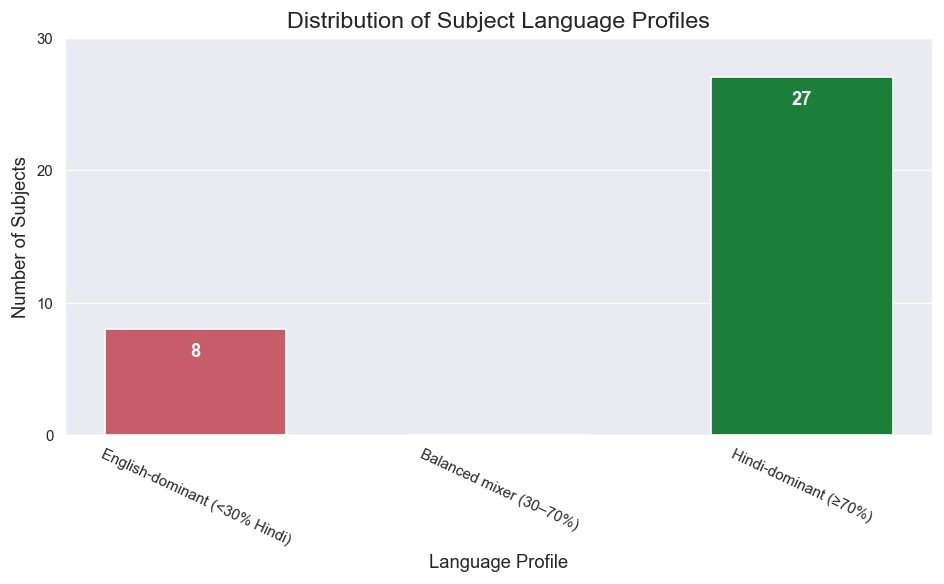

In [41]:
sns.set_style("darkgrid")

# Data
categories = [
    "English-dominant (<30% Hindi)",
    "Balanced mixer (30–70%)",
    "Hindi-dominant (≥70%)"
]

colors = ["#c85d6a", "#9aa5b1", "#1b7f3a"]

plt.figure(figsize=(8,5))

bars = plt.bar(categories, values, color=colors, width=0.6)

# Remove vertical grid lines
plt.grid(axis='x', visible=False)

# Set Y-axis scale step = 10
plt.yticks(np.arange(0, 31, 10))

# Titles and labels
plt.title("Distribution of Subject Language Profiles", fontsize=14)
plt.ylabel("Number of Subjects")
plt.xlabel("Language Profile")

# Rotate x labels
plt.xticks(rotation=-25)

# Add value labels
for bar, val in zip(bars, values):
    if val > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val - 1,
            str(val),
            ha='center',
            va='top',
            color='white',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

---
## IRT Histogram

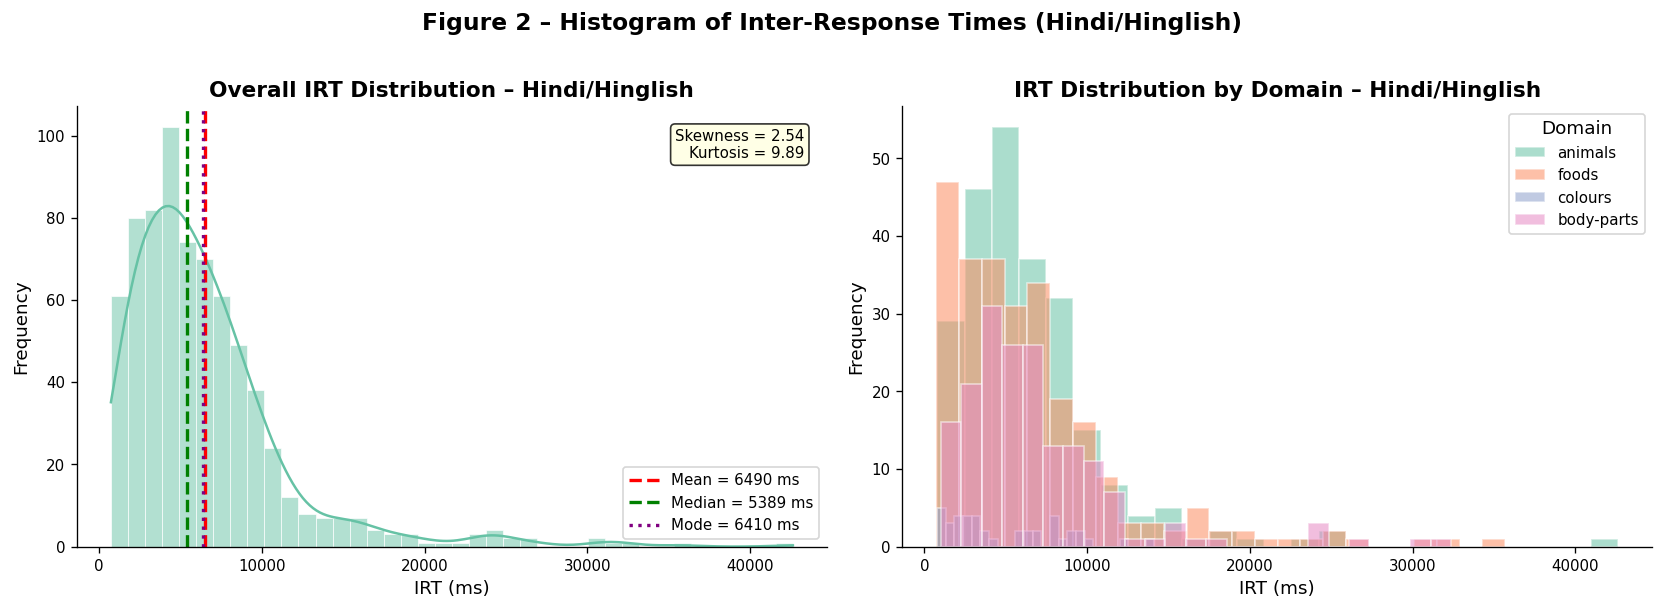

Skewness = 2.544  →  Positively skewed distribution.
Mean (6490 ms) > Median (5389 ms) confirms positive skew.
Most retrievals below 5 000 ms, consistent with cluster-internal rapid access.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: overall IRT histogram ───────────────────────────────────────────────
ax = axes[0]
sns.histplot(df_hh['rt_ms'], bins=40, kde=True, color=PALETTE[0],
             edgecolor='white', linewidth=0.4, ax=ax)
mean_v  = df_hh['rt_ms'].mean()
med_v   = df_hh['rt_ms'].median()
mode_v  = df_hh['rt_ms'].mode().iloc[0]
ax.axvline(mean_v,  color='red',    linestyle='--', linewidth=2, label=f'Mean = {mean_v:.0f} ms')
ax.axvline(med_v,   color='green',  linestyle='--', linewidth=2, label=f'Median = {med_v:.0f} ms')
ax.axvline(mode_v,  color='purple', linestyle=':',  linewidth=2, label=f'Mode = {mode_v:.0f} ms')
ax.set_xlabel('IRT (ms)')
ax.set_ylabel('Frequency')
ax.set_title('Overall IRT Distribution – Hindi/Hinglish', fontweight='bold')
ax.legend(fontsize=9)
skew_val = df_hh['rt_ms'].skew()
ax.text(0.97, 0.95, f'Skewness = {skew_val:.2f}\nKurtosis = {df_hh["rt_ms"].kurtosis():.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

# ── Right: domain-stratified ──────────────────────────────────────────────────
ax2 = axes[1]
for i, dom in enumerate(domains_ord):
    sub = df_hh[df_hh['domain'] == dom]['rt_ms']
    ax2.hist(sub, bins=25, alpha=0.55, color=PALETTE[i], label=dom, edgecolor='white')
ax2.set_xlabel('IRT (ms)')
ax2.set_ylabel('Frequency')
ax2.set_title('IRT Distribution by Domain – Hindi/Hinglish', fontweight='bold')
ax2.legend(title='Domain', fontsize=9)

fig.suptitle('Figure 2 – Histogram of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness = {skew_val:.3f}  →  Positively skewed distribution.")
print(f"Mean ({mean_v:.0f} ms) > Median ({med_v:.0f} ms) confirms positive skew.")
print("Most retrievals below 5 000 ms, consistent with cluster-internal rapid access.")

VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish
  Mean cluster size (words/cluster) : 4.99
  SD cluster size                   : 2.05
  Mean switches per participant      : 1.9
  Mean total clusters                : 4.5

Per-domain cluster statistics:
            mean_cluster_size  n_switches
domain                                   
animals                  5.02        0.93
body-parts               5.24        0.62
colours                  4.06        1.50
foods                    5.56        0.50



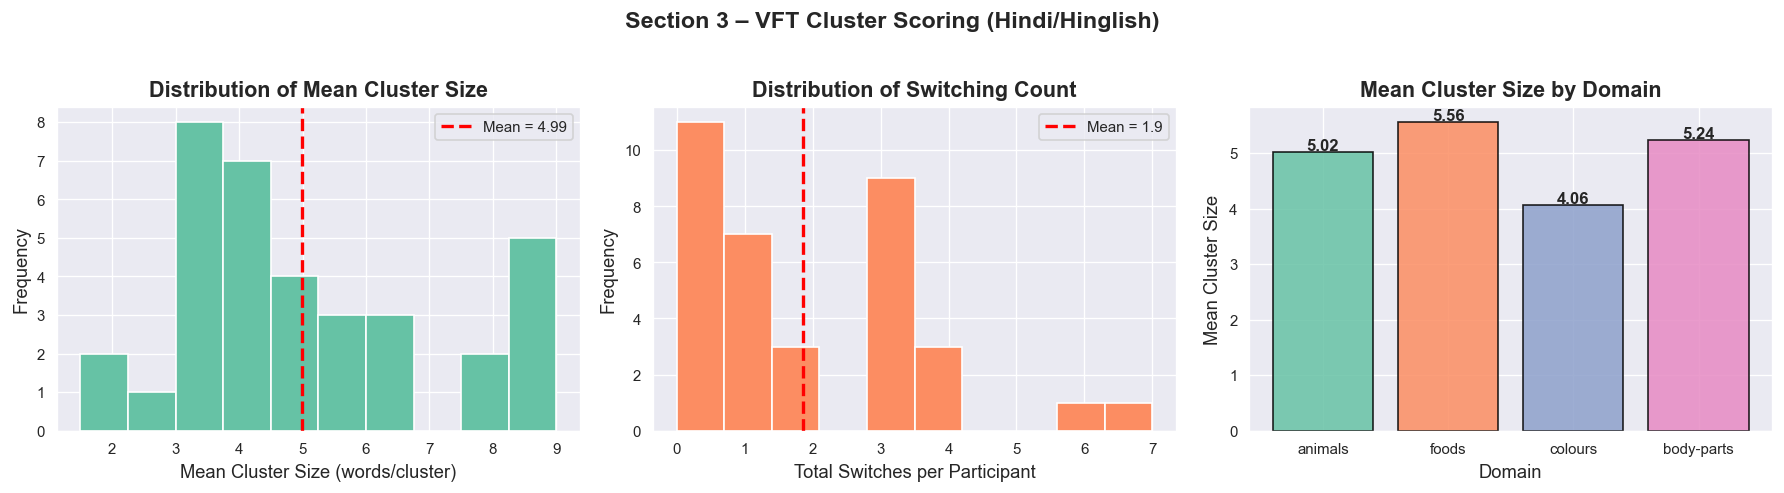

In [35]:
import pandas as pd
import numpy as np

cluster_records = []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 2:
        continue
    # Switch criterion: IRT > mean + 1 SD (individual threshold per subject-domain sequence)
    threshold = np.mean(irts) + np.std(irts, ddof=1)

    cluster_sizes = []
    current_size  = 1
    switches      = 0

    for i in range(1, len(irts)):
        if irts[i] > threshold:
            cluster_sizes.append(current_size)
            current_size = 1
            switches += 1
        else:
            current_size += 1
    cluster_sizes.append(current_size)  # last cluster

    cluster_records.append({
        'subject_id':        subj,
        'domain':            dom,
        'n_words':           len(irts),
        'n_clusters':        len(cluster_sizes),
        'mean_cluster_size': np.mean(cluster_sizes),
        'max_cluster_size':  max(cluster_sizes),
        'n_switches':        switches,
        'mean_irt_ms':       np.mean(irts),
    })

cluster_df = pd.DataFrame(cluster_records)

# Aggregate per participant
cluster_summary = cluster_df.groupby('subject_id').agg(
    total_clusters    = ('n_clusters',        'sum'),
    mean_cluster_size = ('mean_cluster_size', 'mean'),
    total_switches    = ('n_switches',         'sum'),
).reset_index()

# Merge cluster metrics into fluency table
fluency = fluency.merge(cluster_summary, on='subject_id', how='left')
for col in ['mean_cluster_size', 'total_clusters', 'total_switches']:
    fluency[col] = fluency[col].round(2)

print("=" * 65)
print("VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish")
print("=" * 65)
print(f"  Mean cluster size (words/cluster) : {fluency['mean_cluster_size'].mean():.2f}")
print(f"  SD cluster size                   : {fluency['mean_cluster_size'].std():.2f}")
print(f"  Mean switches per participant      : {fluency['total_switches'].mean():.1f}")
print(f"  Mean total clusters                : {fluency['total_clusters'].mean():.1f}")
print()

print("Per-domain cluster statistics:")
print(cluster_df.groupby('domain')[['mean_cluster_size', 'n_switches']].mean().round(2).to_string())
print()

# Plot cluster size distribution and switch count distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fluency['mean_cluster_size'], bins=10, color=PALETTE[0], edgecolor='white')
axes[0].axvline(fluency['mean_cluster_size'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['mean_cluster_size'].mean():.2f}")
axes[0].set_xlabel('Mean Cluster Size (words/cluster)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Mean Cluster Size', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].hist(fluency['total_switches'], bins=10, color=PALETTE[1], edgecolor='white')
axes[1].axvline(fluency['total_switches'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['total_switches'].mean():.1f}")
axes[1].set_xlabel('Total Switches per Participant')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Switching Count', fontweight='bold')
axes[1].legend(fontsize=9)

dom_cluster = cluster_df.groupby('domain')['mean_cluster_size'].mean().reindex(domains_ord)
bars = axes[2].bar(dom_cluster.index, dom_cluster.values,
                   color=[dom_colors[d] for d in dom_cluster.index],
                   edgecolor='black', alpha=0.85)
for bar, val in zip(bars, dom_cluster.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Domain')
axes[2].set_ylabel('Mean Cluster Size')
axes[2].set_title('Mean Cluster Size by Domain', fontweight='bold')

fig.suptitle('Section 3 – VFT Cluster Scoring (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Raincloud Plot (IRT by Domain)

**Figure 6** – Raincloud plot combining kernel density estimate, box (Q1–Q3 + median dot), and individual IRT scatter (raindrops) for each domain. Bandwidth-adjusted KDE (bw=0.3) highlights the bimodal within-/between-cluster IRT structure.

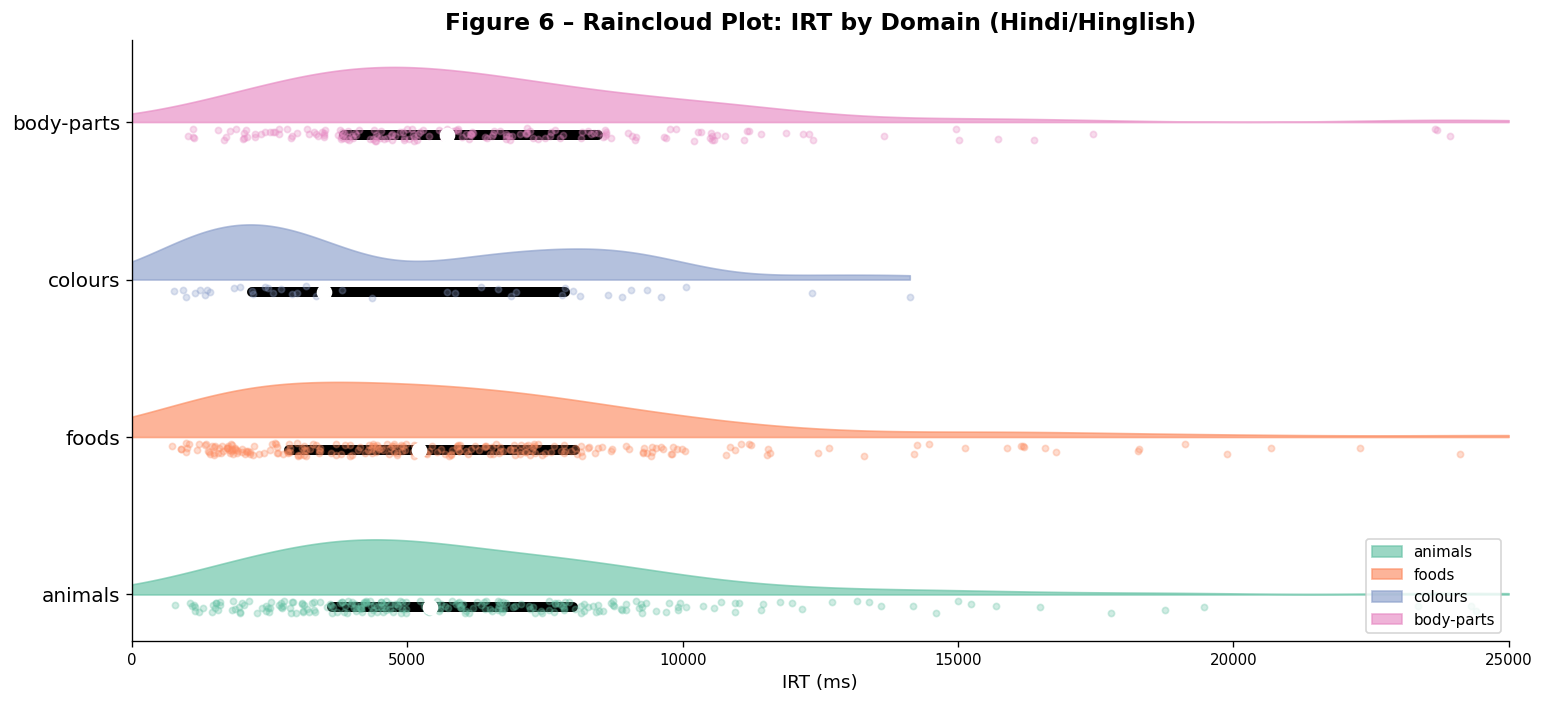

Interpretation:
Dense cloud at low IRTs (<5 000 ms) → rapid cluster-internal access.
Isolated raindrops above 10 000 ms → cluster-switch pauses.


In [14]:
fig, ax = plt.subplots(figsize=(13, 6))

for i, dom in enumerate(domains_ord):
    sub = df_hh[df_hh['domain'] == dom]['rt_ms'].values
    y_pos = i

    # KDE cloud (top half)
    kde = gaussian_kde(sub, bw_method=0.3)
    cap = min(sub.max(), 25000)
    irt_range = np.linspace(0, cap, 300)
    kde_vals  = kde(irt_range)
    kde_vals  = kde_vals / kde_vals.max() * 0.35
    ax.fill_between(irt_range, y_pos, y_pos + kde_vals,
                    color=PALETTE[i], alpha=0.65, label=dom)

    # Box (below centre line)
    q1_, q3_, med_ = np.percentile(sub, [25, 75, 50])
    ax.plot([q1_, q3_], [y_pos - 0.08, y_pos - 0.08],
            color='black', linewidth=6, solid_capstyle='round')
    ax.scatter(med_, y_pos - 0.08, color='white', s=70, zorder=6)

    # Raindrops
    rng = np.random.default_rng(i)
    jitter = rng.uniform(-0.12, -0.04, len(sub))
    ax.scatter(sub, y_pos + jitter, color=PALETTE[i], alpha=0.3, s=14, zorder=4)

ax.set_yticks(range(len(domains_ord)))
ax.set_yticklabels(domains_ord, fontsize=12)
ax.set_xlabel('IRT (ms)')
ax.set_title('Figure 6 – Raincloud Plot: IRT by Domain (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 25000)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("Dense cloud at low IRTs (<5 000 ms) → rapid cluster-internal access.")
print("Isolated raindrops above 10 000 ms → cluster-switch pauses.")

---
## Fluency Scores per Participant

Total words produced (`total_words`) is the primary fluency score. A summary table aggregates fluency, mean IRT, median IRT, domain breadth, and dominant language per participant.

In [16]:
fluency = df_hh.groupby('subject_id').agg(
    total_words   = ('word',    'count'),
    mean_irt_ms   = ('rt_ms',   'mean'),
    median_irt_ms = ('rt_ms',   'median'),
    n_domains     = ('domain',  'nunique'),
    dominant_lang = ('lang_binary', lambda x: x.value_counts().index[0])
).reset_index()

fluency['mean_irt_ms']   = fluency['mean_irt_ms'].round(1)
fluency['median_irt_ms'] = fluency['median_irt_ms'].round(1)
fluency = fluency.sort_values('total_words', ascending=False).reset_index(drop=True)

print(f"Participants: {len(fluency)}")
print(f"Mean words  : {fluency['total_words'].mean():.1f}")
print(f"Median words: {fluency['total_words'].median():.0f}")
print(f"Min / Max   : {fluency['total_words'].min()} / {fluency['total_words'].max()}")
fluency.head(10)

Participants: 35
Mean words  : 20.3
Median words: 22
Min / Max   : 5 / 47


,subject_id,total_words,mean_irt_ms,median_irt_ms,n_domains,dominant_lang
0,92821,47,3142.9,1913.3,3,Hindi/Hinglish
1,73233,37,4378.9,3117.5,3,Hindi/Hinglish
2,61476,30,4162.5,2257.4,3,Hindi/Hinglish
3,78839,30,5675.9,4622.6,3,Hindi/Hinglish
4,35389,28,5823.9,3386.6,3,Hindi/Hinglish
5,20970,27,5887.1,4949.2,3,Hindi/Hinglish
6,68981,27,6063.7,4320.0,3,Hindi/Hinglish
7,43909,26,4497.2,4418.8,3,Hindi/Hinglish
8,13549,26,6271.5,5282.5,3,Hindi/Hinglish
9,72898,25,6728.0,4528.8,3,Hindi/Hinglish


---
## Adaptive Cluster Scoring (Troyer Algorithm)

Clusters are identified by an individual threshold: IRT > mean + 1 SD triggers a cluster boundary. For each participant × domain, we record `n_clusters`, `mean_cluster_size`, `max_cluster_size`, and `n_switches`. These are merged into the `fluency` table.

In [17]:
cluster_records = []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 2:
        continue

    # Adaptive threshold: mean + 1 SD for this participant × domain
    threshold     = np.mean(irts) + np.std(irts, ddof=1)
    cluster_sizes = []
    current_size  = 1
    switches      = 0

    for i in range(1, len(irts)):
        if irts[i] > threshold:
            cluster_sizes.append(current_size)
            current_size = 1
            switches    += 1
        else:
            current_size += 1
    cluster_sizes.append(current_size)  # close last cluster

    cluster_records.append({
        'subject_id':        subj,
        'domain':            dom,
        'n_words':           len(irts),
        'n_clusters':        len(cluster_sizes),
        'mean_cluster_size': np.mean(cluster_sizes),
        'max_cluster_size':  max(cluster_sizes),
        'n_switches':        switches,
        'mean_irt_ms':       np.mean(irts),
    })

cluster_df = pd.DataFrame(cluster_records)

# Aggregate to participant level and merge into fluency table
cluster_summary = cluster_df.groupby('subject_id').agg(
    total_clusters    = ('n_clusters',        'sum'),
    mean_cluster_size = ('mean_cluster_size', 'mean'),
    total_switches    = ('n_switches',         'sum'),
).reset_index()

fluency = fluency.merge(cluster_summary, on='subject_id', how='left')
for col in ['mean_cluster_size', 'total_clusters', 'total_switches']:
    fluency[col] = fluency[col].round(2)

print("=" * 65)
print("VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish")
print("=" * 65)
print(f"  Mean cluster size (words/cluster) : {fluency['mean_cluster_size'].mean():.2f}")
print(f"  SD cluster size                   : {fluency['mean_cluster_size'].std():.2f}")
print(f"  Mean switches per participant      : {fluency['total_switches'].mean():.1f}")
print(f"  Mean total clusters                : {fluency['total_clusters'].mean():.1f}")

VFT CLUSTER SCORING SUMMARY  –  Hindi/Hinglish
  Mean cluster size (words/cluster) : 4.99
  SD cluster size                   : 2.05
  Mean switches per participant      : 1.9
  Mean total clusters                : 4.5


---
## Fluency vs Mean IRT Bubble Plot (All Participants)

**Figure 9** – Bubble scatter of mean IRT vs total words. Bubble size encodes domain breadth; colour encodes dominant language. The OLS trend and Pearson *r* indicate whether faster retrievers score higher fluency.

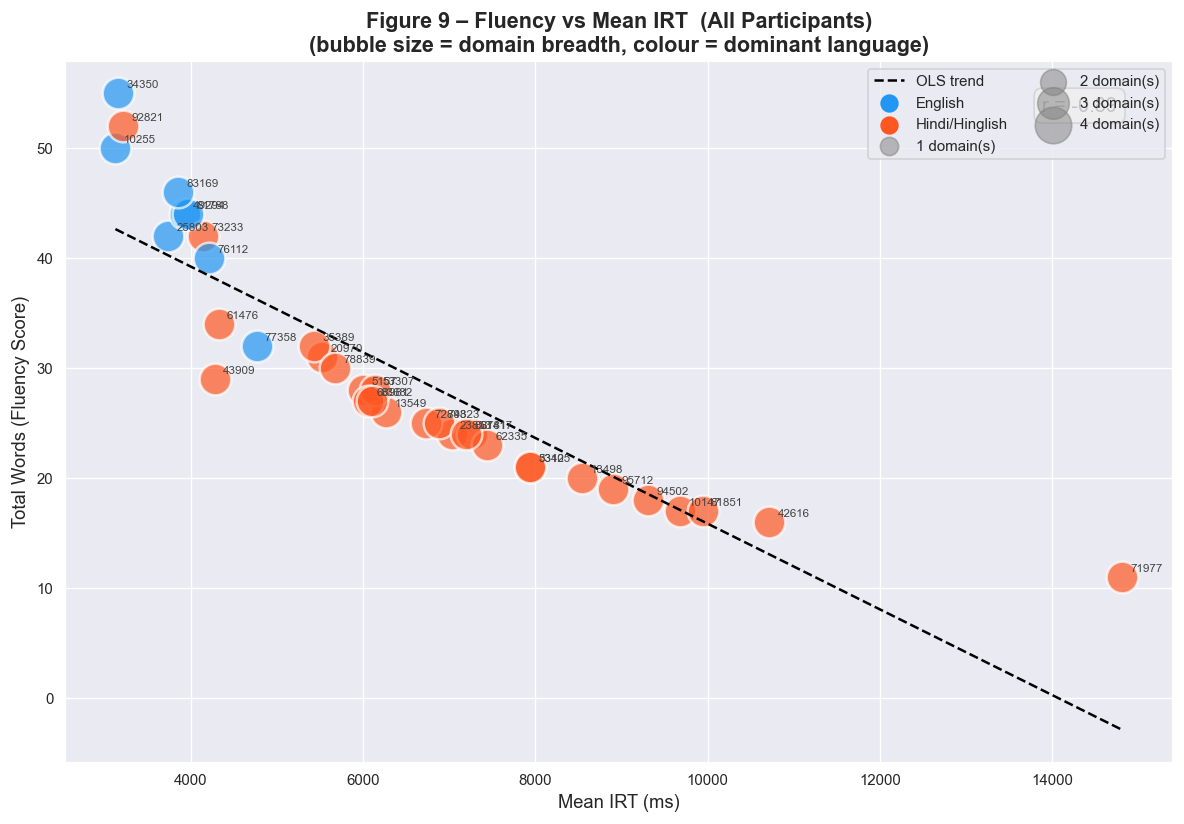

Pearson r = -0.889  →  negative correlation (mean IRT vs fluency).


In [ ]:
fluency_all = df_clean.groupby('subject_id').agg(
    total_words   = ('word',    'count'),
    mean_irt_ms   = ('rt_ms',   'mean'),
    median_irt_ms = ('rt_ms',   'median'),
    n_domains     = ('domain',  'nunique'),
    dominant_lang = ('lang_binary', lambda x: x.value_counts().index[0])
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))

lang_colors = {'English': '#2196F3', 'Hindi/Hinglish': '#FF5722'}
for _, row in fluency_all.iterrows():
    color = lang_colors.get(row['dominant_lang'], '#9E9E9E')
    size  = row['n_domains'] * 120
    ax.scatter(row['mean_irt_ms'], row['total_words'],
               s=size, color=color, alpha=0.7, edgecolors='white', lw=1.5)
    ax.annotate(str(row['subject_id'])[:8], (row['mean_irt_ms'], row['total_words']),
                textcoords='offset points', xytext=(5, 3), fontsize=7, color='#444')

z  = np.polyfit(fluency_all['mean_irt_ms'], fluency_all['total_words'], 1)
xs = np.linspace(fluency_all['mean_irt_ms'].min(), fluency_all['mean_irt_ms'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label='OLS trend')

r = np.corrcoef(fluency_all['mean_irt_ms'], fluency_all['total_words'])[0, 1]
ax.text(0.95, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray'))

for lang, c in lang_colors.items():
    ax.scatter([], [], color=c, s=100, label=lang)
for nd, s in [(1, 120), (2, 240), (3, 360), (4, 480)]:
    ax.scatter([], [], s=s, color='gray', alpha=0.5, label=f'{nd} domain(s)')

ax.set_xlabel('Mean IRT (ms)')
ax.set_ylabel('Total Words (Fluency Score)')
ax.set_title('Figure 9 – Fluency vs Mean IRT  (All Participants)\n'
             '(bubble size = domain breadth, colour = dominant language)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

direction = "negative" if r < 0 else "positive"
print(f"Pearson r = {r:.3f}  →  {direction} correlation (mean IRT vs fluency).")


---
## RQ1: Within-Cluster vs Between-Cluster IRT

**Hypothesis:** Between-cluster IRTs are significantly longer than within-cluster IRTs (Welch's independent-samples *t*-test, two-tailed, α = .05). Cohen's *d* quantifies effect magnitude.

In [20]:
def cohens_d(a, b):
    """Pooled Cohen's d for two independent samples."""
    na, nb   = len(a), len(b)
    pooled_s = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 +
                        (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_s if pooled_s > 0 else 0.0

separator = "=" * 65

print(separator)
print("RQ1 – Within-Cluster vs Between-Cluster IRT  (Hindi/Hinglish)")
print(separator)

within_irts, between_irts = [], []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 3:
        continue
    mean_irt     = irts.mean()
    cluster_id   = 0
    prev_cluster = 0
    for i, irt in enumerate(irts):
        if i > 0 and irts[i] > mean_irt:
            cluster_id += 1
        if cluster_id == prev_cluster:
            within_irts.append(irt)
        else:
            between_irts.append(irt)
        prev_cluster = cluster_id

t_stat_rq1, p_val_rq1 = stats.ttest_ind(between_irts, within_irts, equal_var=False)
d_rq1  = cohens_d(between_irts, within_irts)
sig1   = "Significant" if p_val_rq1 < 0.05 else "Not significant"

print(f"  Within-cluster  IRT:  mean = {np.mean(within_irts):.0f} ms  |  n = {len(within_irts)}")
print(f"  Between-cluster IRT:  mean = {np.mean(between_irts):.0f} ms  |  n = {len(between_irts)}")
print(f"  Welch's t = {t_stat_rq1:.3f},  p = {p_val_rq1:.4f},  Cohen's d = {d_rq1:.3f}")
print(f"  Result: {sig1} (α = 0.05)")
print(f"  Between-cluster IRT is {np.mean(between_irts)/np.mean(within_irts):.2f}× within-cluster IRT")

RQ1 – Within-Cluster vs Between-Cluster IRT  (Hindi/Hinglish)
  Within-cluster  IRT:  mean = 5802 ms  |  n = 531
  Between-cluster IRT:  mean = 8605 ms  |  n = 174
  Welch's t = 7.672,  p = 0.0000,  Cohen's d = 0.574
  Result: Significant (α = 0.05)
  Between-cluster IRT is 1.48× within-cluster IRT


---
## RQ1 Visualisation

**Figure 10** – Bar chart comparing mean within-cluster vs between-cluster IRT, with SEM error bars and significance annotation. This supports or refutes the cluster-switch pause hypothesis.

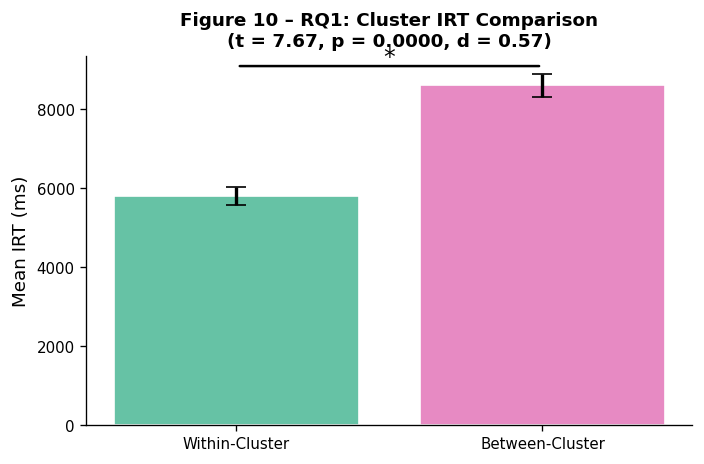

Effect size (Cohen's d) = 0.57 → medium


In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
means = [np.mean(within_irts), np.mean(between_irts)]
sems  = [stats.sem(within_irts), stats.sem(between_irts)]

ax.bar(['Within-Cluster', 'Between-Cluster'], means, yerr=sems,
       color=[PALETTE[0], PALETTE[3]], edgecolor='white',
       capsize=6, error_kw={'lw': 2})
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'Figure 10 – RQ1: Cluster IRT Comparison\n'
             f'(t = {t_stat_rq1:.2f}, p = {p_val_rq1:.4f}, d = {d_rq1:.2f})',
             fontsize=11, fontweight='bold')

if p_val_rq1 < 0.05:
    y_max = max(means) + max(sems) + 200
    ax.annotate('', xy=(1, y_max), xytext=(0, y_max),
                arrowprops=dict(arrowstyle='-', lw=1.5))
    ax.text(0.5, y_max + 50, '*', ha='center', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Effect size (Cohen's d) = {d_rq1:.2f} → {'large' if abs(d_rq1) >= 0.8 else 'medium' if abs(d_rq1) >= 0.5 else 'small'}")

---
## RQ2: Effect of Language Type on IRT

**Hypothesis:** Hindi/Hinglish responses differ in IRT from English responses (Welch's *t*-test). This tests whether code-mixed retrieval patterns change retrieval speed.

────────────────────────────────────────────────────────────
RQ2 – Mean Cluster Size vs Total Fluency
────────────────────────────────────────────────────────────
  r(33) = 0.54,  p < .001,  95% CI [0.26, 0.74]
  Total words = 7.73 + 2.53 * Mean cluster size
  F(1,33) = 13.9,  p < .001,  R² = 0.30

  Decision: Reject H0.
  Cluster depth explains 30% of fluency variance;
  each unit increase in mean cluster size predicts ~2.5 additional Hindi words.
────────────────────────────────────────────────────────────


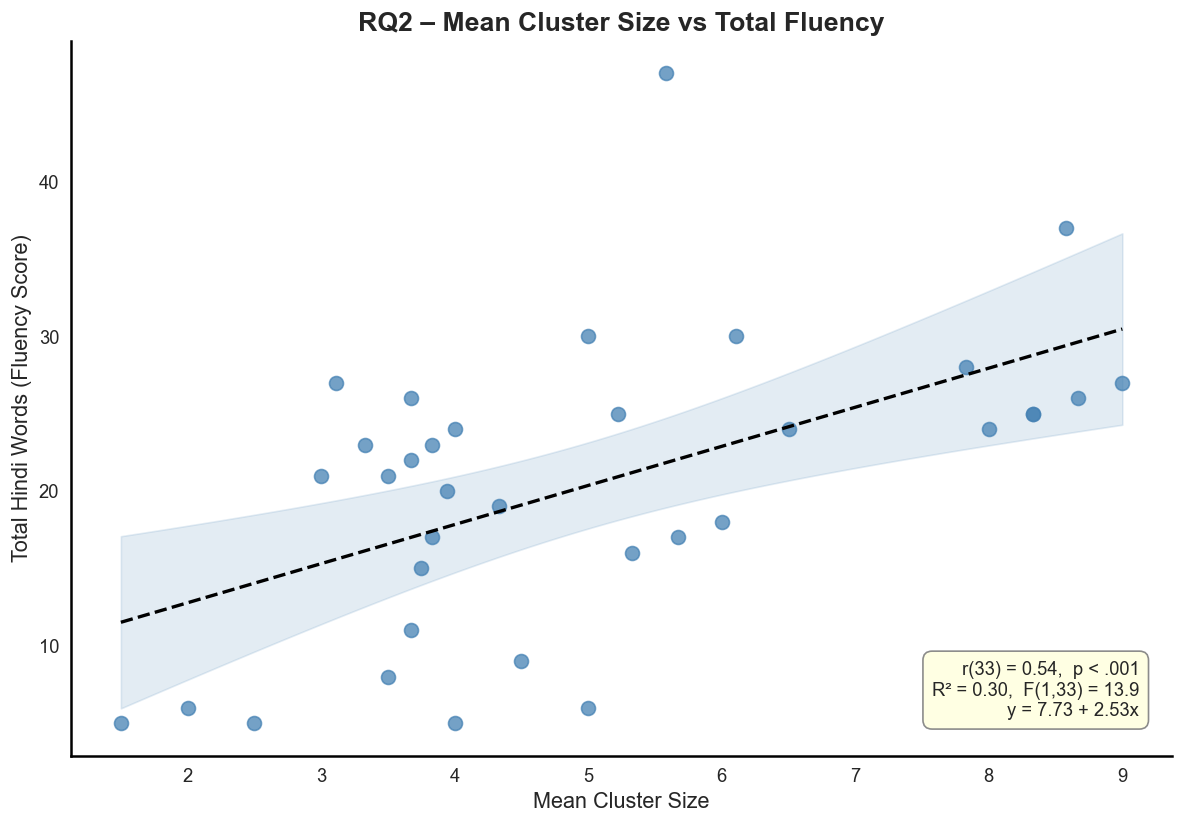

In [53]:
from scipy import stats as scipy_stats
import numpy as np
import matplotlib.pyplot as plt

# ── Build per-participant summary from fluency DataFrame ──────────────────────
# fluency already has mean_cluster_size and total_words after cluster scoring
rq2_df = fluency[['mean_cluster_size', 'total_words']].dropna()

x = rq2_df['mean_cluster_size'].values.astype(float)
y = rq2_df['total_words'].values.astype(float)

n = len(x)

# ── OLS regression ────────────────────────────────────────────────────────────
slope, intercept, r_value, p_value, se_slope = scipy_stats.linregress(x, y)
r2     = r_value ** 2
df_reg = n - 2
f_stat = r2 * df_reg / (1 - r2)

# 95% CI for r  (Fisher z-transform)
z      = np.arctanh(r_value)
se_z   = 1 / np.sqrt(n - 3)
z_crit = scipy_stats.norm.ppf(0.975)
r_lo   = np.tanh(z - z_crit * se_z)
r_hi   = np.tanh(z + z_crit * se_z)

# Regression line + 95% CI band
x_line  = np.linspace(x.min(), x.max(), 300)
y_line  = intercept + slope * x_line

# Standard error of fitted values
x_mean = x.mean()
s_res  = np.sqrt(np.sum((y - (intercept + slope * x))**2) / df_reg)
se_fit = s_res * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
t_crit = scipy_stats.t.ppf(0.975, df_reg)
ci_lo  = y_line - t_crit * se_fit
ci_hi  = y_line + t_crit * se_fit

# ── Print statistics ──────────────────────────────────────────────────────────
sep = "─" * 60
print(sep)
print("RQ2 – Mean Cluster Size vs Total Fluency")
print(sep)
print(f"  r({df_reg}) = {r_value:.2f},  p {'< .001' if p_value < .001 else f'= {p_value:.3f}'},  "
      f"95% CI [{r_lo:.2f}, {r_hi:.2f}]")

print(f"  Total words = {intercept:.2f} + {slope:.2f} * Mean cluster size")

print(f"  F(1,{df_reg}) = {f_stat:.1f},  p {'< .001' if p_value < .001 else f'= {p_value:.3f}'},  "
      f"R² = {r2:.2f}")

p_decision = p_value < 0.05
print(f"\n  Decision: {'Reject' if p_decision else 'Fail to reject'} H0.")
print(f"  Cluster depth explains {r2*100:.0f}% of fluency variance;")
print(f"  each unit increase in mean cluster size predicts ~{slope:.1f} additional Hindi words.")
print(sep)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# White background
ax.set_facecolor('#ffffff')
fig.patch.set_facecolor('white')

# Show X and Y axis lines clearly
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Scatter points
ax.scatter(x, y, color='steelblue', s=70, alpha=0.75, zorder=3)

# Regression line
ax.plot(x_line, y_line, color='black', lw=2, linestyle='--', zorder=4)

# Confidence interval
ax.fill_between(x_line, ci_lo, ci_hi, color='steelblue', alpha=0.15, zorder=2)

# Stats annotation box
stats_txt = (
    f"r({df_reg}) = {r_value:.2f},  p {'< .001' if p_value < .001 else f'= {p_value:.3f}'}\n"
    f"R² = {r2:.2f},  F(1,{df_reg}) = {f_stat:.1f}\n"
    f"y = {intercept:.2f} + {slope:.2f}x"
)

ax.text(
    0.97, 0.05,
    stats_txt,
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=11,
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='lightyellow',
        edgecolor='gray',
        alpha=0.9
    )
)

# Axis labels
ax.set_xlabel('Mean Cluster Size', fontsize=13)
ax.set_ylabel('Total Hindi Words (Fluency Score)', fontsize=13)

# Title
ax.set_title(
    'RQ2 – Mean Cluster Size vs Total Fluency',
    fontsize=16,
    fontweight='bold'
)

ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

RQ2 – Effect of Language Type on IRT  (All Participants)
  English IRT        : mean = 3642 ms  |  SD = 2919  |  n = 332
  Hindi/Hinglish IRT : mean = 6490 ms  |  SD = 5015  |  n = 712
  Welch's t = -11.519,  p = 0.0000,  Cohen's d = -0.638
  Result: Significant (α = 0.05)


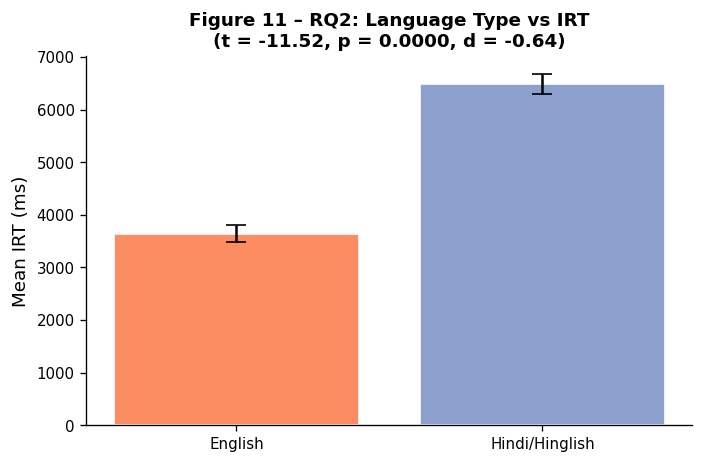

In [22]:
print(separator)
print("RQ2 – Effect of Language Type on IRT  (All Participants)")
print(separator)

irt_eng = df_clean[df_clean['language_type'] == 'English']['rt_ms'].values
irt_hin = df_clean[df_clean['language_type'] == 'Hindi/Hinglish']['rt_ms'].values

t_stat_rq2, p_val_rq2 = stats.ttest_ind(irt_eng, irt_hin, equal_var=False)
d_rq2  = cohens_d(irt_eng, irt_hin)
sig2   = "Significant" if p_val_rq2 < 0.05 else "Not significant"

print(f"  English IRT        : mean = {np.mean(irt_eng):.0f} ms  |  SD = {np.std(irt_eng):.0f}  |  n = {len(irt_eng)}")
print(f"  Hindi/Hinglish IRT : mean = {np.mean(irt_hin):.0f} ms  |  SD = {np.std(irt_hin):.0f}  |  n = {len(irt_hin)}")
print(f"  Welch's t = {t_stat_rq2:.3f},  p = {p_val_rq2:.4f},  Cohen's d = {d_rq2:.3f}")
print(f"  Result: {sig2} (α = 0.05)")

fig, ax = plt.subplots(figsize=(6, 4))
means2 = [np.mean(irt_eng), np.mean(irt_hin)]
sems2  = [stats.sem(irt_eng), stats.sem(irt_hin)]
ax.bar(['English', 'Hindi/Hinglish'], means2, yerr=sems2,
       color=[PALETTE[1], PALETTE[2]], edgecolor='white', capsize=6)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'Figure 11 – RQ2: Language Type vs IRT\n'
             f'(t = {t_stat_rq2:.2f}, p = {p_val_rq2:.4f}, d = {d_rq2:.2f})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position
(These will be paired with SpAM semantic distances for RQ2)

--- ANIMALS ---
  word  freq  mean_irt_ms  mean_position  n_participants
कुत्ता    15       7843.0           2.93              15
   शेर    15      10387.4           3.27              15
बिल्ली    11       5660.5           3.18              11
  हाथी    11       6625.7           5.27              11
 kutta     9       5638.3           2.56               9
  sher     9       3041.0           4.33               9
   गाय     9      11354.5           2.33               9
 billi     7       1732.2           2.57               7
 घोड़ा     7       6168.0           5.43               7
   बाघ     7       5189.8           4.00               7

--- FOODS ---
  word  freq  mean_irt_ms  mean_position  n_participants
  चावल    14      10956.7           2.64              14
  roti     9      11972.4           1.89               9
   दाल     9       9059.8           3.11

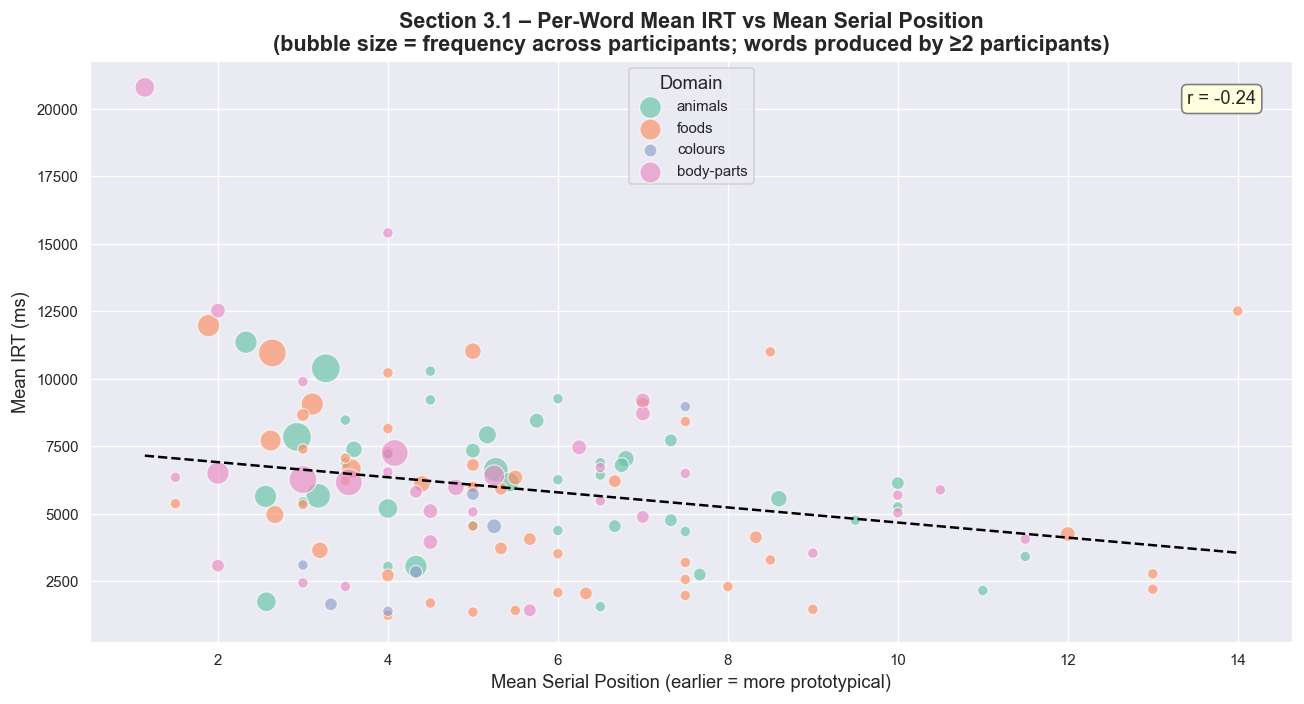

Correlation (mean position vs mean IRT, words with freq≥2): r = -0.238
NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.

word_irt table saved as 'word_irt' DataFrame for future SpAM merge.


In [52]:
word_irt = (
    df_hh.groupby(['domain', 'word'])
    .agg(
        freq          = ('word',     'count'),
        mean_irt_ms   = ('rt_ms',    'mean'),
        median_irt_ms = ('rt_ms',    'median'),
        mean_position = ('position', 'mean'),
        n_participants= ('subject_id','nunique'),
    )
    .reset_index()
    .assign(
        mean_irt_ms   = lambda x: x['mean_irt_ms'].round(1),
        median_irt_ms = lambda x: x['median_irt_ms'].round(1),
        mean_position = lambda x: x['mean_position'].round(2),
    )
    .sort_values(['domain', 'freq'], ascending=[True, False])
)

print("TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position")
print("(These will be paired with SpAM semantic distances for RQ2)\n")
for dom in domains_ord:
    sub = word_irt[word_irt['domain'] == dom].head(10)
    print(f"--- {dom.upper()} ---")
    print(sub[['word','freq','mean_irt_ms','mean_position','n_participants']].to_string(index=False))
    print()

# Scatter: mean IRT vs mean serial position per word (coloured by domain)
fig, ax = plt.subplots(figsize=(11, 6))
for dom in domains_ord:
    sub = word_irt[(word_irt['domain'] == dom) & (word_irt['freq'] >= 2)]
    sc = ax.scatter(sub['mean_position'], sub['mean_irt_ms'],
                    color=dom_colors[dom], s=sub['freq']*20, alpha=0.65,
                    edgecolors='white', lw=0.8, label=dom)

ax.set_xlabel('Mean Serial Position (earlier = more prototypical)', fontsize=11)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title('Section 3.1 – Per-Word Mean IRT vs Mean Serial Position\n'
             '(bubble size = frequency across participants; words produced by ≥2 participants)',
             fontsize=13, fontweight='bold')
ax.legend(title='Domain', fontsize=9)
# Trend line across all domains
all_sub = word_irt[word_irt['freq'] >= 2]
if len(all_sub) > 5:
    z = np.polyfit(all_sub['mean_position'], all_sub['mean_irt_ms'], 1)
    xs = np.linspace(all_sub['mean_position'].min(), all_sub['mean_position'].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label='Trend (all domains)')
    r_word = np.corrcoef(all_sub['mean_position'], all_sub['mean_irt_ms'])[0, 1]
    ax.text(0.97, 0.95, f'r = {r_word:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
plt.tight_layout()
plt.show()

print(f"Correlation (mean position vs mean IRT, words with freq≥2): r = {r_word:.3f}")
print("NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.")
print("\nword_irt table saved as 'word_irt' DataFrame for future SpAM merge.")
